# Finetune Llama 3.2-1B-Instruct on Banking77 Intent Classification

**Model:** Llama 3.2-1B-Instruct (unsloth/optimized)  
**Strategy:** Parameter-Efficient Fine-Tuning (LoRA + DoRA + rsLoRA)  
**Task:** Intent Classification (77 banking intents from Banking77 dataset)  
**Framework:** Unsloth + TRL SFTTrainer  
**Hardware:** Kaggle P100/T4 GPU  
**Duration:** ~15-20 minutes per epoch

## 1. Intall Dependecies

In [1]:
# Install Unsloth (optimized for Kaggle)
!pip install -q "unsloth[kaggle-new] @ git+https://github.com/unslothai/unsloth.git"

# Upgrade core training libraries to latest
#!pip install -q --upgrade trl peft accelerate transformers  datasets 
!pip install -q wandb matplotlib liger-kernel

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 428.0/428.0 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.3/199.3 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 92.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 114.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 660.6/660.6 kB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 99.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 11.8 MB

## 2. Configuration

**Model & Quantization:**
- 4-bit quantization (QLoRA) reduces VRAM from 8GB to ~2GB
- Max sequence length: 512 tokens (sufficient for short banking queries)

**PEFT (LoRA + DoRA + rsLoRA):**
- Rank: 32 (higher capacity for intent-specific knowledge)
- DoRA: Decomposes LoRA into magnitude and direction for stable training
- rsLoRA: Rank-stabilized for better gradient flow at higher ranks
- LoRA dropout: 0 (DoRA provides sufficient regularization)

**Training Setup:**
- 1 epoch over deduplicated 9K training samples (rapid iteration)
- Effective batch: 32 (8 per-device × 4 accumulation steps)
- Cosine LR scheduler with 5% warmup
- Response-only loss masking: Learn only on assistant responses
- Packing: Multiple short sequences into one for efficiency
- No NEFTune: Focus on clean, efficient single-epoch training

**Infrastructure:**
- W&B integration: Full experiment tracking
- Checkpoint saving: Keep 3 best checkpoints, save at epoch end
- Automatic best model loading at training end

In [ ]:
import os
import gc
from datetime import datetime
import matplotlib.pyplot as plt

import torch
from datasets import load_from_disk
from unsloth import FastLanguageModel

import wandb

# === CONSTANTS ===
# Llama-3 specific template used to identify where the assistant's response begins
RESPONSE_TEMPLATE = "<|start_header_id|>assistant<|end_header_id|>\n\n"

# Paths for input data and output artifacts on Kaggle
DATASET_PATH = "/kaggle/input/datasets/tranphungdinh/banking77-hf-processed/processed/template"
OUTPUT_DIR = "/kaggle/working/outputs"
CHECKPOINT_DIR = f"{OUTPUT_DIR}/checkpoints"
FINAL_MODEL_DIR = f"{OUTPUT_DIR}/finetuned_model"

# Ensure the checkpoint directory exists
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# === CONFIGURATION ===
config = {
    "model": {
        "name": "unsloth/Llama-3.2-1B-Instruct",
        "max_seq_length": 512,
        "load_in_4bit": True,
    },
    "peft": {
        "r": 32,
        "lora_alpha": 32,
        "lora_dropout": 0,
        "use_dora": True,
        "use_rslora": True,
        "target_modules": ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
        "bias": "none",
        "use_gradient_checkpointing": "unsloth"
    },
    "wandb": {
        "project": "banking77-finetuning",
        "run_name": f"llama3.2-1b-dora-{datetime.now().strftime('%Y%m%d-%H%M')}",
    },
    "training": {
        "num_train_epochs": 1,
        "per_device_train_batch_size": 8,
        "per_device_eval_batch_size": 8,
        "gradient_accumulation_steps": 4,
        "learning_rate": 2.0e-4,
        "lr_scheduler_type": "cosine",
        "warmup_ratio": 0.05,
        "weight_decay": 0.01,
        "max_grad_norm": 1.0,
        "fp16": True,
        "bf16": False,
        "optim": "adamw_8bit",
        "logging_steps": 10,
        "save_strategy": "epoch",
        "eval_strategy": "epoch",
        "save_total_limit": 3,
        "load_best_model_at_end": True,
        "metric_for_best_model": "eval_loss",
        "greater_is_better": False
    }
}

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


## 3. Load Dataset and Base Model

In [3]:
import os
import shutil

# Copy dataset to writable directory
WRITABLE_DATASET_PATH = "/kaggle/working/writable_dataset"

print("1. Copying dataset to /kaggle/working (writable directory)...")
if os.path.exists(WRITABLE_DATASET_PATH):
    shutil.rmtree(WRITABLE_DATASET_PATH)  # Remove old copy if re-running the cell
shutil.copytree(DATASET_PATH, WRITABLE_DATASET_PATH)

print("2. Loading formatted dataset...")
# Load dataset from writable path
ds = load_from_disk(WRITABLE_DATASET_PATH)
print(f"Loaded splits: {list(ds.keys())}")

print("\n3. Loading base Llama model with Unsloth...")
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=config["model"]["name"],
    max_seq_length=config["model"]["max_seq_length"],
    dtype=None,
    load_in_4bit=config["model"]["load_in_4bit"],
)

# Pad token for Llama 3
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id
tokenizer.padding_side = "right"

print("\n4. Applying PEFT (LoRA / DoRA) adapters...")
model = FastLanguageModel.get_peft_model(
    model,
    r=config["peft"]["r"],
    lora_alpha=config["peft"]["lora_alpha"],
    lora_dropout=config["peft"]["lora_dropout"],
    target_modules=config["peft"]["target_modules"],
    bias=config["peft"]["bias"],
    use_dora=config["peft"]["use_dora"],
    use_rslora=config["peft"]["use_rslora"],
    use_gradient_checkpointing=config["peft"]["use_gradient_checkpointing"],
    random_state=42,
)

model.print_trainable_parameters()

1. Copying dataset to /kaggle/working (writable directory)...
2. Loading formatted dataset...
Loaded splits: ['train', 'val', 'test']

3. Loading base Llama model with Unsloth...
==((====))==  Unsloth 2026.5.2: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/1.10G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/234 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

Unsloth: Will load unsloth/llama-3.2-1b-instruct-unsloth-bnb-4bit as a legacy tokenizer.
Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.



4. Applying PEFT (LoRA / DoRA) adapters...


Unsloth 2026.5.2 patched 16 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


trainable params: 22,921,216 || all params: 1,258,735,616 || trainable%: 1.8210


## 4. Finetune

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: tpdinh2612 (tpdinh2612-vnuhcm-university-of-science) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Tracking run with wandb version 0.25.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260506_073349-kfjxlvv5
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run llama3.2-1b-dora-20260506-0733
wandb: ⭐️ View project at https://wandb.ai/tpdinh2612-vnuhcm-university-of-science/banking77-finetuning
wandb: 🚀 View run at https://wandb.ai/tpdinh2612-vnuhcm-university-of-science/banking77-finetun

4. Initializing trainer configuration...


Unsloth: Tokenizing ["text"] (num_proc=1):   0%|          | 0/9002 [00:00<?, ? examples/s]

Unsloth: Packing train dataset (num_proc=1):   0%|          | 0/9002 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=1):   0%|          | 0/1001 [00:00<?, ? examples/s]

...

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,639 | Num Epochs = 3 | Total steps = 309
O^O/ \_/ \    Batch size per device = 8 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (8 x 2 x 1) = 16
 "-____-"     Trainable parameters = 22,921,216 of 1,258,735,616 (1.82% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss,Validation Loss
50,0.774901,0.041660
100,0.036107,0.031332
150,0.029500,0.030329
200,0.027601,0.028719
250,0.024829,0.028183


Unsloth: Restored added_tokens_decoder metadata in /kaggle/working/outputs/checkpoints/checkpoint-50/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /kaggle/working/outputs/checkpoints/checkpoint-100/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /kaggle/working/outputs/checkpoints/checkpoint-150/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /kaggle/working/outputs/checkpoints/checkpoint-200/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /kaggle/working/outputs/checkpoints/checkpoint-250/tokenizer_config.json.
wandb: updating run metadata
wandb: uploading history steps 9-10, summary, console lines 19-19
wandb: 
wandb: Run history:
wandb:               eval/loss █▃▂▁▁
wandb:            eval/runtime █▂▁▁▂
wandb: eval/samples_per_second ▁▇█▇▇
wandb:   eval/steps_per_second ▁████
wandb:             train/epoch ▁▁▃▃▅▅▆▆███
wandb:       train/global_step ▁▁▃▃▅▅▆▆███
wandb:         trai


6. Extracting loss history and plotting curves...
✅ Loss curve saved to: /kaggle/working/outputs/loss_curve.png


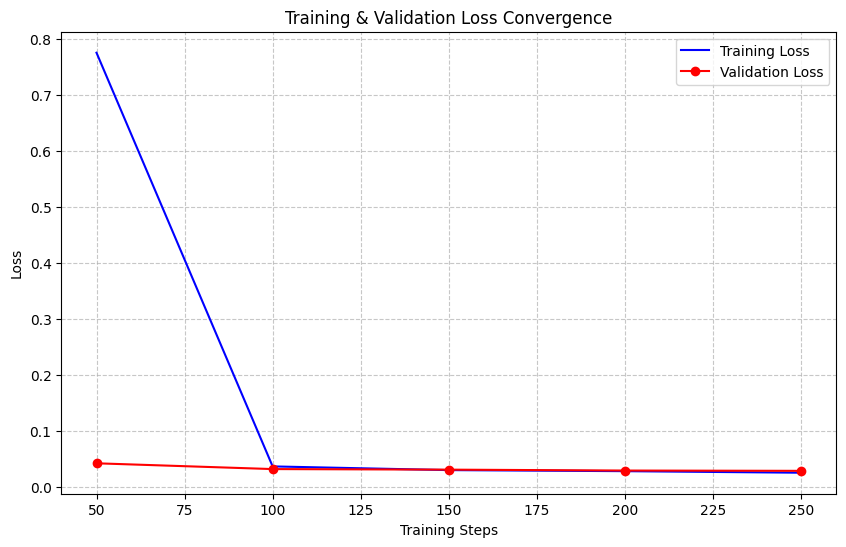

In [ ]:
from trl import SFTConfig, SFTTrainer
from unsloth.chat_templates import train_on_responses_only

from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()

wandb_key = user_secrets.get_secret("WANDB_API_KEY")
wandb.login(key=wandb_key)

# Init
wandb.init(
    project=config["wandb"]["project"],
    name=config["wandb"]["run_name"],
    config=config
)

print("4. Initializing trainer configuration...")

# Set up Supervised Fine-Tuning (SFT) configurations
training_args = SFTConfig(
    output_dir=CHECKPOINT_DIR,
    report_to="wandb",              # Report to external tools like W&B
    dataset_text_field="text",      # The column name in your dataset containing the text
    dataset_num_proc=1,             # Number of processes for dataset preprocessing
    packing=True,                   # Pack multiple short sequences into one to speed up training
    max_seq_length=config["model"]["max_seq_length"], 
    **config["training"]            # Unpack ALL training hyperparameters from config
)

# Initialize SFTTrainer
trainer = SFTTrainer(
    model=model,
    processing_class=tokenizer,     # Essential for encoding the text data
    train_dataset=ds["train"],
    eval_dataset=ds["val"],         # Set evaluation dataset for validation loss tracking
    args=training_args,
)

# Mask out the user prompts and train only on assistant responses
trainer = train_on_responses_only(
    trainer,
    instruction_part="<|start_header_id|>user<|end_header_id|>\n\n",
    response_part="<|start_header_id|>assistant<|end_header_id|>\n\n",
)

print("5. Starting training 🔥")
train_result = trainer.train()
wandb.finish()

# --- PLOT TRAINING LOSS ---
print("\n6. Extracting loss history and plotting curves...")
log_history = trainer.state.log_history

train_steps = []
train_loss = []
eval_steps = []
eval_loss = []

# Iterate through logs to separate training and evaluation metrics
for log in log_history:
    if "loss" in log and "step" in log:
        train_steps.append(log["step"])
        train_loss.append(log["loss"])
    elif "eval_loss" in log and "step" in log:
        eval_steps.append(log["step"])
        eval_loss.append(log["eval_loss"])

# Plot loss curves using matplotlib
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(train_steps, train_loss, label="Training Loss", color="blue")

# Only plot validation loss if it exists in the log history
if eval_steps:
    plt.plot(eval_steps, eval_loss, label="Validation Loss", color="red", marker="o")

plt.title("Training & Validation Loss Convergence")
plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)

# Save plot
loss_img_path = f"{OUTPUT_DIR}/loss_curve.png"
plt.savefig(loss_img_path, dpi=300, bbox_inches="tight")

print(f"✅ Loss curve saved to: {loss_img_path}")
plt.show()

## 5. Save Model

In [5]:
import shutil
import torch
import gc
import os

print("\n7. Saving DoRA adapter weights...")

os.makedirs(FINAL_MODEL_DIR, exist_ok=True)

# Save adapter weights
model.save_pretrained(FINAL_MODEL_DIR)
tokenizer.save_pretrained(FINAL_MODEL_DIR)

# Free up GPU memory
torch.cuda.empty_cache()
gc.collect()

print(f"🎉 Done! DoRA adapters saved at: {FINAL_MODEL_DIR}")

print("\n8. Creating ZIP archive for download...")
ZIP_PATH = "/kaggle/working/finetuned_dora"
shutil.make_archive(ZIP_PATH, "zip", FINAL_MODEL_DIR)

print(f"✅ Archive created: {ZIP_PATH}.zip")


7. Saving DoRA adapter weights...


Unsloth: Restored added_tokens_decoder metadata in /kaggle/working/outputs/finetuned_model/tokenizer_config.json.


🎉 Done! DoRA adapters saved at: /kaggle/working/outputs/finetuned_model

8. Creating ZIP archive for download...
✅ Archive created: /kaggle/working/finetuned_dora.zip
